In [1]:
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd

df_pred = pd.read_csv('../../experiments/exp_2025-06-29/res_config3.json/pred_98.csv',
                      index_col=0, parse_dates=True)
df_ref = pd.read_csv('../../experiments/exp_2025-06-29/res_config3.json/ref_98.csv'
                     , index_col=0, parse_dates=True)

df_pred.drop(columns=['extra'], inplace=True)

In [2]:
df_pred

,1,2,3,4,5,6,7,8
dt,,,,,,,,
2022-06-26 00:00:00+00:00,0.645545,0.570212,0.564805,0.692462,0.611108,0.639801,0.627384,0.666332
2022-08-21 00:00:00+00:00,0.540284,0.575873,0.586025,0.628698,0.686136,0.534591,0.596480,0.633953
2022-10-16 00:00:00+00:00,0.547484,0.489324,0.572513,0.551571,0.517877,0.491520,0.658554,0.586711
2022-12-11 00:00:00+00:00,0.536952,0.642709,0.554361,0.620509,0.625664,0.686424,0.713566,0.713709
2023-02-05 00:00:00+00:00,0.528579,0.488395,0.750970,0.615629,0.514840,0.686637,0.683431,0.588016
2023-04-02 00:00:00+00:00,0.814033,0.781481,0.782333,0.754806,0.793480,0.708003,0.731612,0.719744
2023-05-28 00:00:00+00:00,0.914309,0.801721,0.696365,0.607378,0.565452,0.514138,0.545255,0.504141
2023-07-23 00:00:00+00:00,0.676555,0.646241,0.581036,0.563714,0.675384,0.554630,0.550910,0.524660
2023-09-17 00:00:00+00:00,0.501475,0.517065,0.476008,0.432718,0.459312,0.424743,0.443165,0.486911


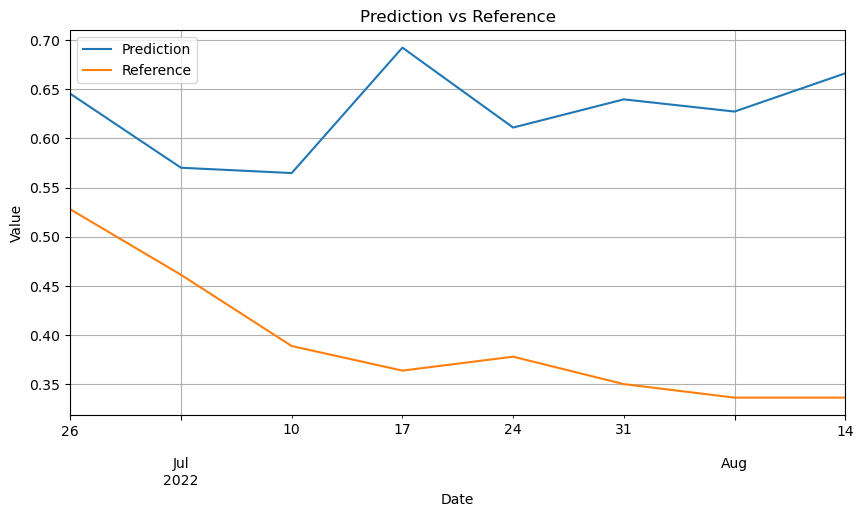

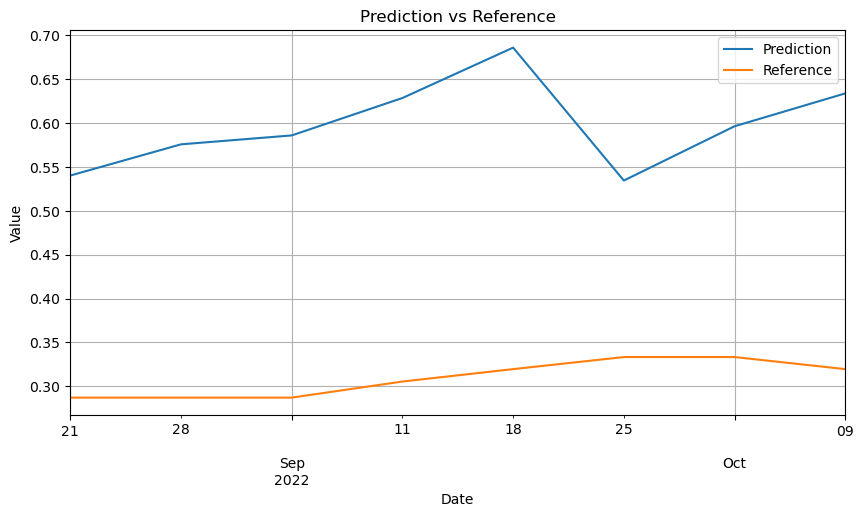

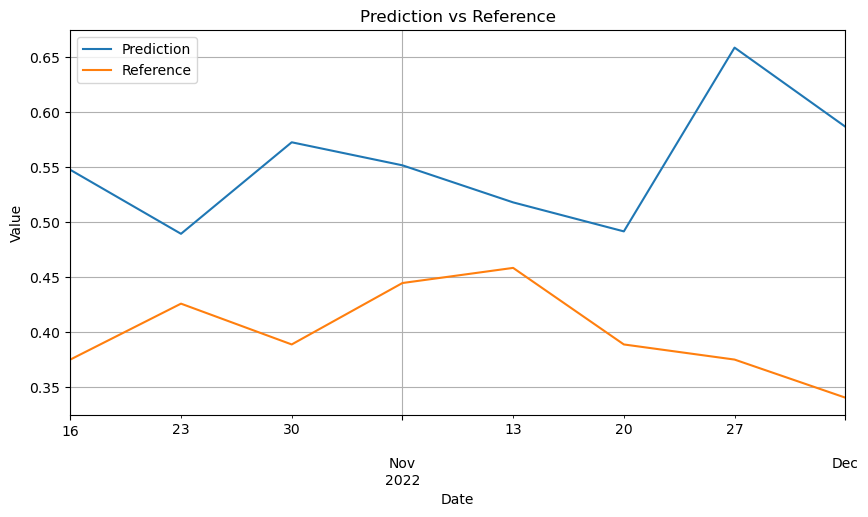

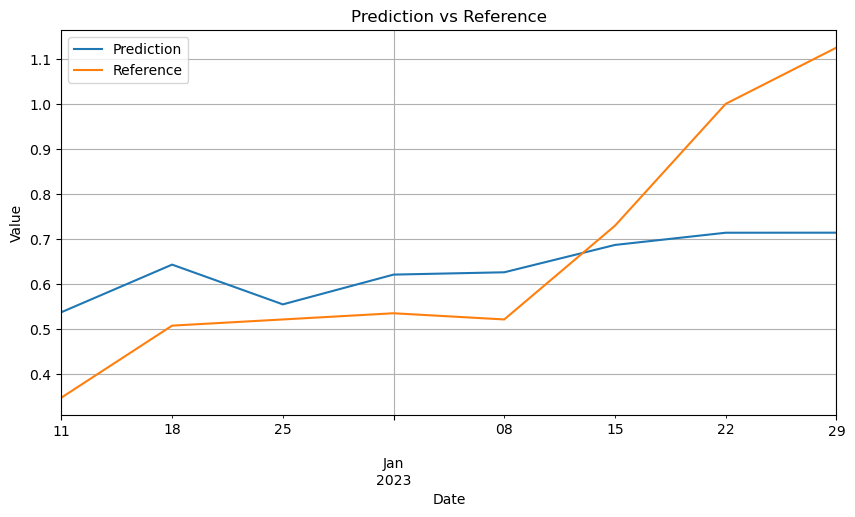

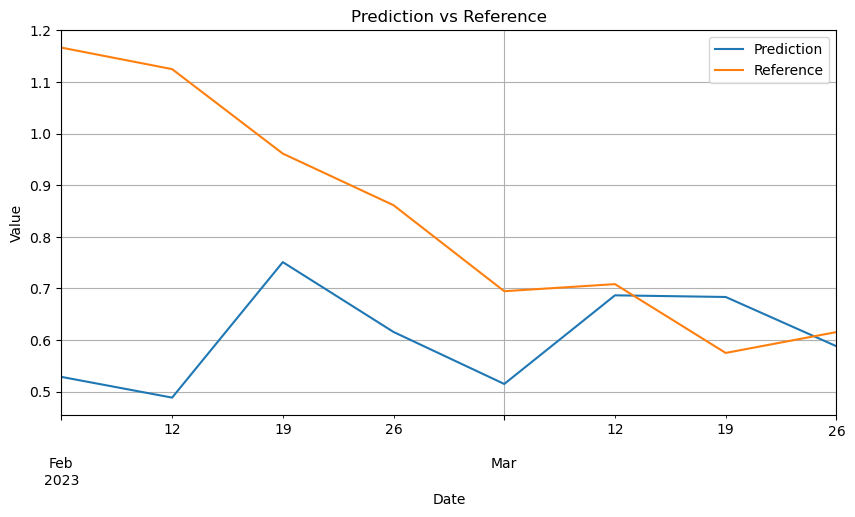

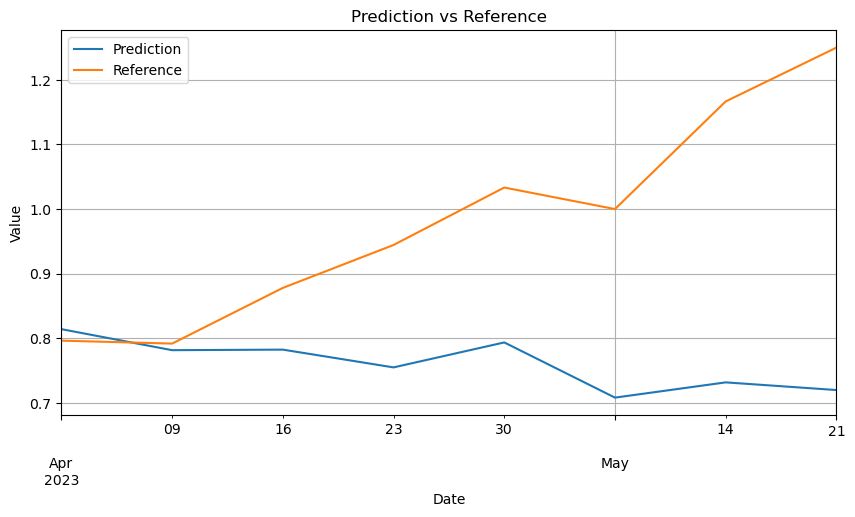

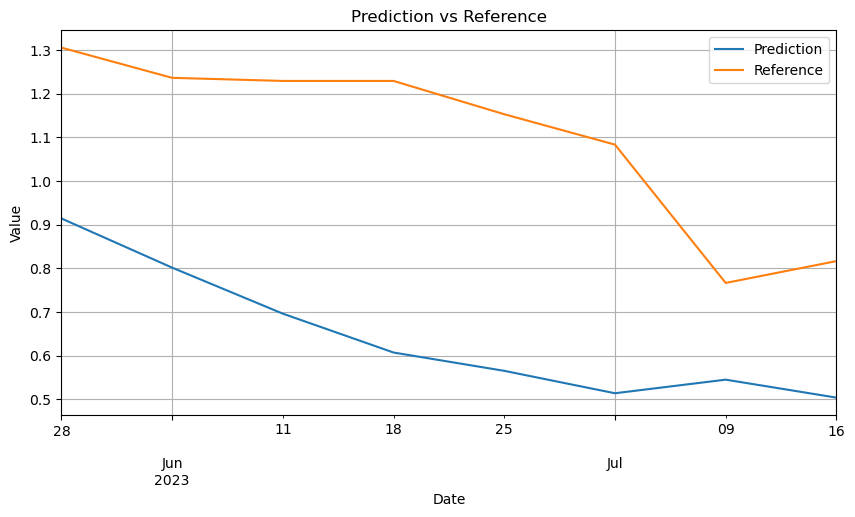

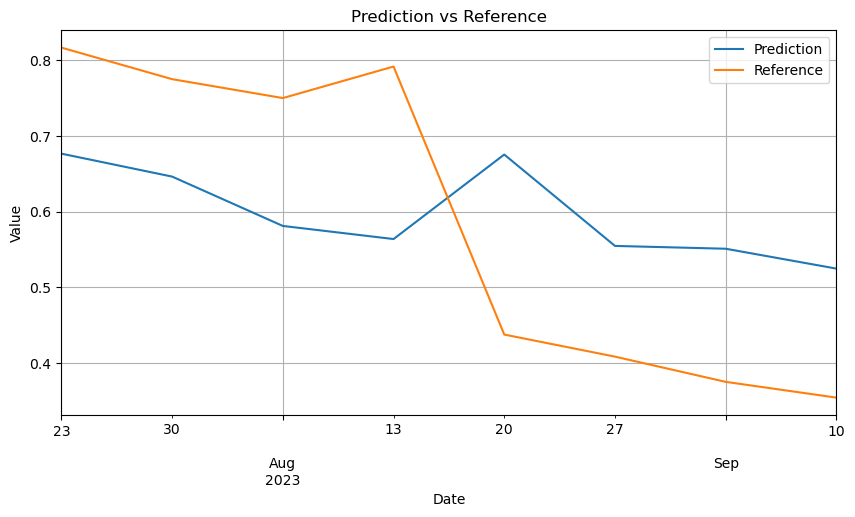

In [3]:
def traspose_series_from_df_row(df_pred, row):
    aux_df = df_pred.reset_index()
    transposed_values = aux_df.iloc[row,:].values
    #transposed_values.extend(aux_df.iloc[:,1].values)
    dates = [transposed_values[0] + timedelta(weeks=i) for i in range(len(transposed_values) -1)]
    transposed_series = pd.Series(transposed_values[1:], index=dates, name='val')
    return transposed_series

def plot_all_ref_pred(df_pred, df_ref):

    for i in range(8):
        traspose_series_pred = traspose_series_from_df_row(df_pred, i)
        traspose_series_ref = traspose_series_from_df_row(df_ref, i)

        #plot

        plt.figure(figsize=(10, 5))
        traspose_series_pred.plot(label='Prediction')
        traspose_series_ref.plot(label='Reference')
        plt.title('Prediction vs Reference')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid()
        plt.show()

plot_all_ref_pred(df_pred, df_ref)